## 0. Setup

In [13]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_curve, auc

warnings.filterwarnings("ignore")

ROOT     = Path("..")
EVAL_DIR = ROOT / "results" / "evaluation"
FIG_DIR  = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Auto-detect which pca_dim was used (pick highest available)
import re as _re
_pca_files = sorted(EVAL_DIR.glob("gp_pca*.json"))
if _pca_files:
    _pca_nums = [int(_re.search(r'gp_pca(\d+)\.json', p.name).group(1)) for p in _pca_files]
    PCA_DIM = max(_pca_nums)
else:
    PCA_DIM = 32
print(f"Using PCA_DIM = {PCA_DIM}")

# ── load GP fold results ──
fold_df  = pd.read_csv(EVAL_DIR / "fold_results.csv")
cat_df   = pd.read_csv(EVAL_DIR / "category_summary.csv")
with open(EVAL_DIR / "evaluation_summary.json") as f:
    summary = json.load(f)

# ── load all method scored folds ──
method_dfs = {}
for method in ("gp", "knn", "maha", "fused"):
    p = EVAL_DIR / f"scored_folds_{method}.json"
    if p.exists():
        method_dfs[method] = pd.DataFrame(json.load(open(p)))

# ── load baseline fold results ──
baseline_dfs = {}
for name in ("ensemble", "mc_dropout", "padim", "patchcore"):
    p = EVAL_DIR / f"baseline_{name}_fold_results.csv"
    if p.exists():
        baseline_dfs[name] = pd.read_csv(p)

print(f"GP folds loaded:      {len(fold_df)}")
print(f"Methods loaded:       {list(method_dfs.keys())}")
print(f"Baselines loaded:     {list(baseline_dfs.keys())}")
print(f"Overall AUROC (GP):   {summary['mean_auroc_do']:.3f} ± {summary['std_auroc_do']:.3f}")
for bname, bauc in summary.get("baseline_mean_auroc", {}).items():
    print(f"  {bname}: {bauc:.3f}")


Using PCA_DIM = 64
GP folds loaded:      72
Methods loaded:       ['gp', 'knn', 'maha', 'fused']
Baselines loaded:     ['ensemble', 'mc_dropout', 'padim', 'patchcore']
Overall AUROC (GP):   0.598 ± 0.168
  ensemble: 0.515
  mc_dropout: 0.514
  padim: 0.507
  patchcore: 0.513


## F1  [REPORT §6] — GP vs Baselines: Per-category AUROC

**Caption:** Mean AUROC (defect-only labelling) per category for the GP model
and each baseline. Error bars = ±1 SD over LODTO folds.
Dashed line = chance (0.5). GP uses posterior variance as the novelty score;
baselines use reconstruction error from autoencoders trained on normal images only.


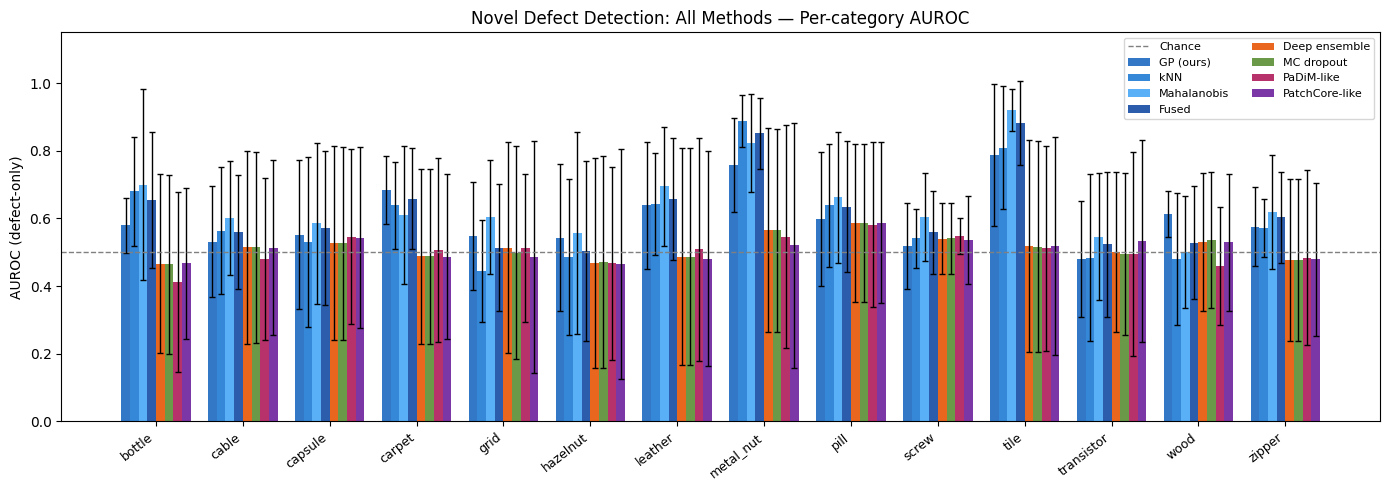

Saved F1_gp_vs_baselines_auroc.png


In [14]:
cats = sorted(fold_df["category"].unique())
x    = np.arange(len(cats))

# All methods to display (ours + baselines)
all_method_info = [
    ("GP (ours)",    fold_df,                     "#1565C0"),
    ("kNN",          method_dfs.get("knn"),        "#1976D2"),
    ("Mahalanobis",  method_dfs.get("maha"),       "#42A5F5"),
    ("Fused",        method_dfs.get("fused"),      "#0D47A1"),
    ("Deep ensemble",baseline_dfs.get("ensemble"),"#E65100"),
    ("MC dropout",   baseline_dfs.get("mc_dropout"),"#558B2F"),
    ("PaDiM-like",   baseline_dfs.get("padim"),    "#AD1457"),
    ("PatchCore-like",baseline_dfs.get("patchcore"),"#6A1B9A"),
]
active = [(label, df, color) for label, df, color in all_method_info if df is not None]
n_methods = len(active)
width = 0.8 / n_methods

fig, ax = plt.subplots(figsize=(14, 5))
for k, (label, mdf, color) in enumerate(active):
    offset = (k - n_methods / 2 + 0.5) * width
    means = [mdf[mdf.category == c]["auroc_do"].mean() if c in mdf.category.values else np.nan for c in cats]
    stds  = [mdf[mdf.category == c]["auroc_do"].std()  if c in mdf.category.values else 0       for c in cats]
    ax.bar(x + offset, means, width, yerr=stds, capsize=2,
           label=label, color=color, alpha=0.88, error_kw={"lw": 1.0})

ax.axhline(0.5, ls="--", color="gray", lw=1, label="Chance")
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=38, ha="right", fontsize=9)
ax.set_ylabel("AUROC (defect-only)")
ax.set_title("Novel Defect Detection: All Methods — Per-category AUROC")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig(FIG_DIR / "F1_gp_vs_baselines_auroc.png")
plt.show()
print("Saved F1_gp_vs_baselines_auroc.png")


## F2  [REPORT §6] — AUROC Heatmap (Category × Held-out Defect Type)

**Caption:** AUROC (defect-only) for each LODTO fold.
Rows = MVTec AD categories; columns = held-out defect types.
Warm colours (→ red) indicate the GP readily distinguishes the novel type
from known defects in that category.


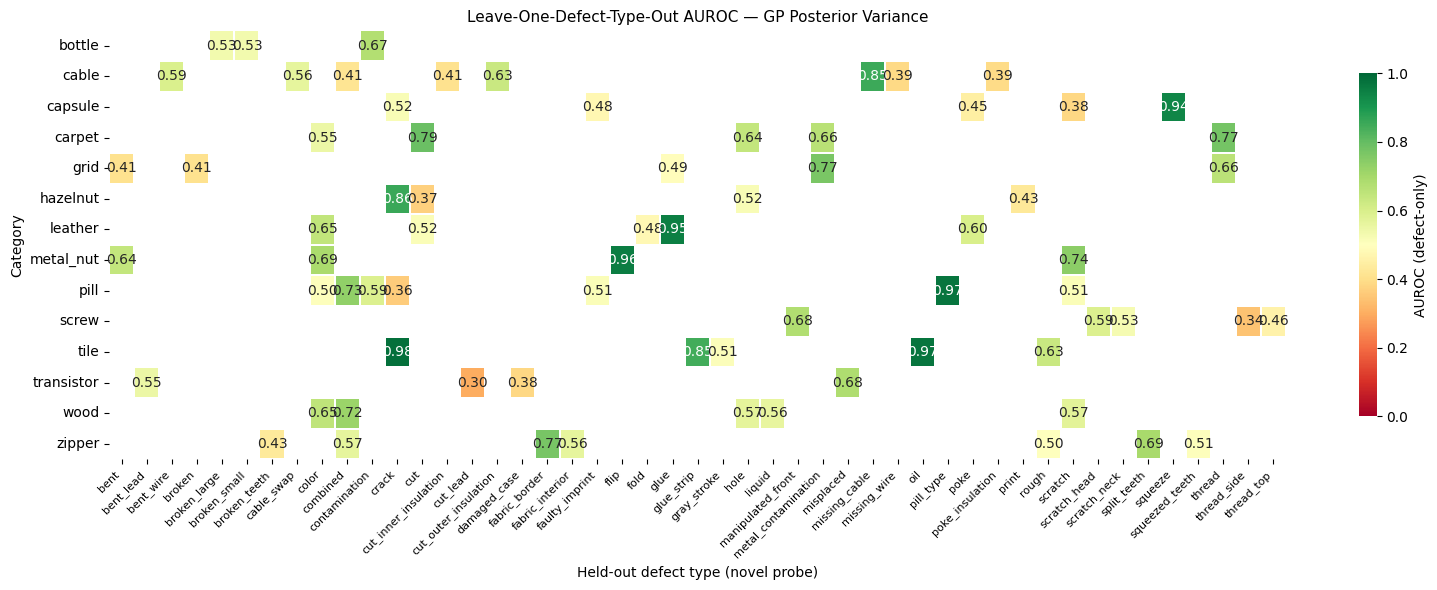

Saved F2_auroc_heatmap.png


In [15]:
pivot = fold_df.pivot_table(index="category", columns="held_out_type", values="auroc_do")

fig, ax = plt.subplots(figsize=(16, 6))
im = sns.heatmap(
    pivot, ax=ax, cmap="RdYlGn", center=0.5, vmin=0, vmax=1,
    annot=True, fmt=".2f", linewidths=0.3,
    cbar_kws={"label": "AUROC (defect-only)", "shrink": 0.8},
)
ax.set_xlabel("Held-out defect type (novel probe)", fontsize=10)
ax.set_ylabel("Category", fontsize=10)
ax.set_title("Leave-One-Defect-Type-Out AUROC — GP Posterior Variance", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "F2_auroc_heatmap.png")
plt.show()
print("Saved F2_auroc_heatmap.png")


## F3  [REPORT §6] — Aggregate ROC Curves

**Caption:** Macro-averaged ROC curves over 72 LODTO folds for each method.
Shaded band = ±1 SD across folds. The Area Under the Curve (AUROC) for each
method is shown in the legend. Defect-only labelling: novel defect type = positive,
known defect types = negative.


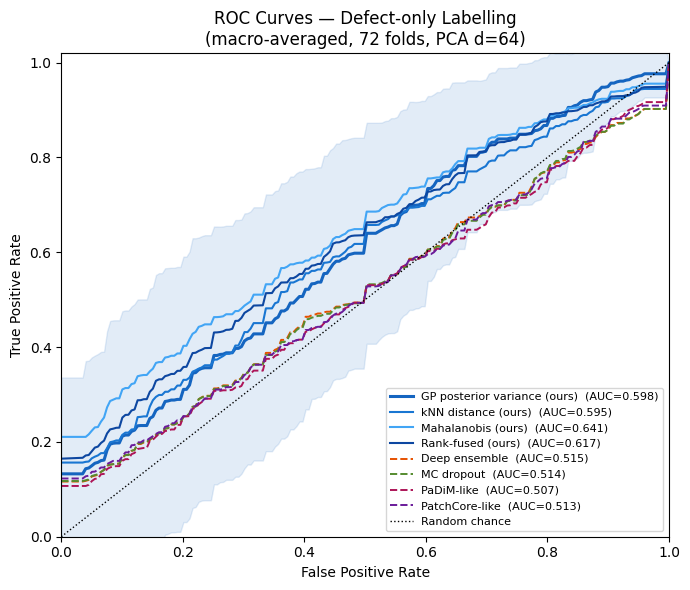

Saved F3_roc_curves.png


In [16]:
def fold_roc(novel_scores, known_scores):
    scores = np.concatenate([novel_scores, known_scores])
    labels = np.concatenate([np.ones(len(novel_scores)), np.zeros(len(known_scores))])
    if len(np.unique(labels)) < 2:
        return None, None, 0.0
    fpr, tpr, _ = roc_curve(labels, scores)
    return fpr, tpr, auc(fpr, tpr)

def interp_roc(fpr_list, tpr_list, n=200):
    mean_fpr = np.linspace(0, 1, n)
    tprs = [np.interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(fpr_list, tpr_list)]
    return mean_fpr, np.array(tprs)

fig, ax = plt.subplots(figsize=(7, 6))

GP_COLORS  = ["#1565C0", "#1976D2", "#42A5F5", "#0D47A1"]
BASE_COLORS = ["#E65100", "#558B2F", "#AD1457", "#6A1B9A"]

# ── Our methods (GP + kNN + Mahal + Fused) ──
our_methods = [
    ("gp",    f"gp_pca{PCA_DIM}.json", "test_scores",  "known_scores",  GP_COLORS[0], "GP posterior variance (ours)"),
    ("knn",   f"gp_pca{PCA_DIM}.json", "knn_test_scores", "knn_known_scores", GP_COLORS[1], "kNN distance (ours)"),
    ("maha",  f"gp_pca{PCA_DIM}.json", "maha_test_scores","maha_known_scores",GP_COLORS[2], "Mahalanobis (ours)"),
    ("fused", f"gp_pca{PCA_DIM}.json", "fused_test_scores","fused_known_scores",GP_COLORS[3],"Rank-fused (ours)"),
]

with open(EVAL_DIR / f"gp_pca{PCA_DIM}.json") as f:
    gp_raw = json.load(f)

for _, fname, test_key, known_key, color, label in our_methods:
    fprs, tprs_list = [], []
    for r in gp_raw:
        if test_key not in r or known_key not in r:
            continue
        novel = np.array(r[test_key])
        known = np.array(r[known_key])
        if len(known) == 0:
            continue
        fpr, tpr, _ = fold_roc(novel, known)
        if fpr is not None:
            fprs.append(fpr); tprs_list.append(tpr)
    if fprs:
        mean_fpr, tpr_arr = interp_roc(fprs, tprs_list)
        mean_tpr = tpr_arr.mean(0); std_tpr = tpr_arr.std(0)
        m_auc = np.mean([auc(f, t) for f, t in zip(fprs, tprs_list)])
        lw = 2.2 if "variance" in label else 1.5
        ax.plot(mean_fpr, mean_tpr, color=color, lw=lw,
                label=f"{label}  (AUC={m_auc:.3f})")
        if "variance" in label:
            ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                            color=color, alpha=0.12)

# ── Baselines ──
base_labels = {"ensemble":"Deep ensemble","mc_dropout":"MC dropout",
               "padim":"PaDiM-like","patchcore":"PatchCore-like"}
for (bname, bdf), color in zip(baseline_dfs.items(), BASE_COLORS):
    bpath = ROOT / "results" / "baseline_results" / bname
    b_fprs, b_tprs = [], []
    for _, row in bdf.iterrows():
        fpath = bpath / f"{row['fold_id']}.json"
        if not fpath.exists():
            continue
        with open(fpath) as f:
            br = json.load(f)
        novel = np.array(br["test_scores"])
        known = np.array(br.get("known_scores", []))
        if len(known) == 0:
            continue
        fpr, tpr, _ = fold_roc(novel, known)
        if fpr is not None:
            b_fprs.append(fpr); b_tprs.append(tpr)
    if b_fprs:
        _, b_tpr_arr = interp_roc(b_fprs, b_tprs)
        b_mean = b_tpr_arr.mean(0)
        b_auc  = np.mean([auc(f, t) for f, t in zip(b_fprs, b_tprs)])
        ax.plot(mean_fpr, b_mean, color=color, lw=1.4, ls="--",
                label=f"{base_labels.get(bname, bname)}  (AUC={b_auc:.3f})")

ax.plot([0, 1], [0, 1], "k:", lw=1, label="Random chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves — Defect-only Labelling\n(macro-averaged, 72 folds, PCA d={PCA_DIM})")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(FIG_DIR / "F3_roc_curves.png")
plt.show()
print("Saved F3_roc_curves.png")


## F4  [REPORT §6] — Statistical Comparison Table (Wilcoxon + Holm)

**Caption:** Two-sided Wilcoxon signed-rank test comparing GP AUROC against each
baseline across 72 matched folds, with Holm-Bonferroni correction.
* = significant at α = 0.05 after correction.


                Baseline  W-statistic p-value p (Holm) Sig. (Holm)
     fused_lofz_vs_proto        250.0  0.0000   0.0000          ✓*
     fused_lofz_vs_padim        302.0  0.0000   0.0000          ✓*
 fused_lofz_vs_patchcore        330.0  0.0000   0.0000          ✓*
  fused_lofz_vs_ensemble        302.0  0.0000   0.0000          ✓*
fused_lofz_vs_mc_dropout        309.0  0.0000   0.0000          ✓*
       fused_lofz_vs_lof        334.0  0.0000   0.0000          ✓*
        fused_lofz_vs_gp        382.0  0.0000   0.0000          ✓*
       fused_lofz_vs_knn        398.0  0.0000   0.0000          ✓*
     fused_lofz_vs_fused        401.0  0.0000   0.0000          ✓*
      fused_lofz_vs_maha        462.5  0.0000   0.0001          ✓*
             gp_vs_padim        740.5  0.0013   0.0129          ✓*
        gp_vs_mc_dropout        738.0  0.0020   0.0178          ✓*
    fused_lofz_vs_fused2        765.0  0.0021   0.0165          ✓*
         gp_vs_patchcore        750.0  0.0025   0.0174        

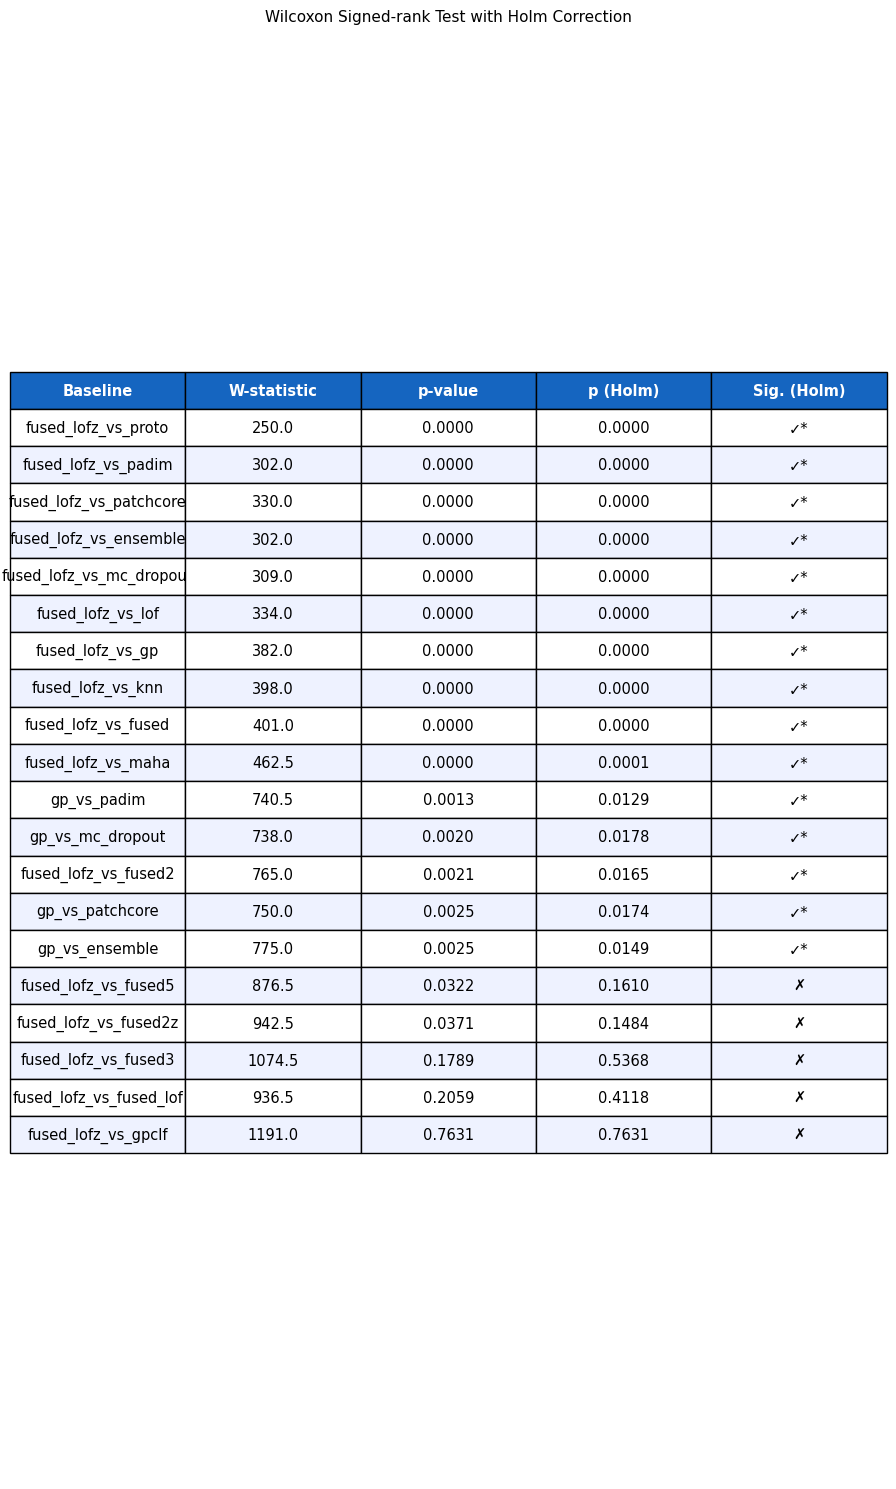

Saved F4_wilcoxon_table.png


In [17]:
tests = summary["wilcoxon_tests"]
tdf = pd.DataFrame(tests)[["method", "statistic", "p_value", "p_holm", "significant_holm"]]
tdf.columns = ["Baseline", "W-statistic", "p-value", "p (Holm)", "Sig. (Holm)"]
tdf["Sig. (Holm)"] = tdf["Sig. (Holm)"].map({True: "✓*", False: "✗"})
tdf["p-value"] = tdf["p-value"].apply(lambda x: f"{x:.4f}")
tdf["p (Holm)"] = tdf["p (Holm)"].apply(lambda x: f"{x:.4f}")

print(tdf.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, max(2, len(tdf) * 0.7 + 1)))
ax.axis("off")
tbl = ax.table(cellText=tdf.values, colLabels=tdf.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10.5)
tbl.scale(1.2, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1565C0"); cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#EEF2FF")

ax.set_title("Wilcoxon Signed-rank Test with Holm Correction", pad=18, fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "F4_wilcoxon_table.png", bbox_inches="tight")
plt.show()
print("Saved F4_wilcoxon_table.png")


## F5  [REPORT §8] — Held-out Severity vs AUROC

**Caption:** Each point is one LODTO fold. x-axis = mean severity of the held-out
novel type; y-axis = AUROC (defect-only).  If high-severity folds cluster at high
AUROC the GP may exploit intensity, not novelty; absence of correlation confirms
the signal is geometric (embedding space), not photometric.


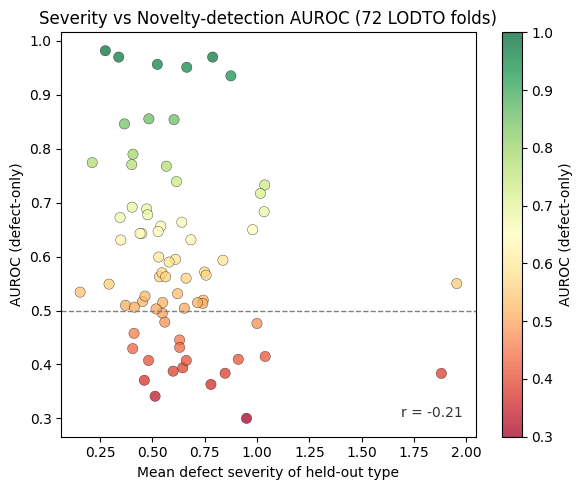

Saved F5_severity_vs_auroc.png   (Pearson r = -0.210)


In [18]:
# parse test_severity (stored as list string or float)
def mean_sev(val):
    if isinstance(val, str):
        import ast
        try: return np.mean(ast.literal_eval(val))
        except: return np.nan
    return float(val)

fold_df["mean_test_sev"] = fold_df["rmse_log_severity"]

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    fold_df["mean_test_sev"], fold_df["auroc_do"],
    c=fold_df["auroc_do"], cmap="RdYlGn", vmin=0.3, vmax=1.0,
    s=55, alpha=0.75, edgecolors="k", linewidths=0.3,
)
plt.colorbar(sc, ax=ax, label="AUROC (defect-only)")
ax.axhline(0.5, ls="--", color="gray", lw=1)

# correlation annotation
valid = fold_df[["mean_test_sev","auroc_do"]].dropna()
r = np.corrcoef(valid["mean_test_sev"], valid["auroc_do"])[0,1]
ax.text(0.97, 0.05, f"r = {r:.2f}", transform=ax.transAxes,
        ha="right", fontsize=10, color="#333")

ax.set_xlabel("Mean defect severity of held-out type")
ax.set_ylabel("AUROC (defect-only)")
ax.set_title("Severity vs Novelty-detection AUROC (72 LODTO folds)")

plt.tight_layout()
plt.savefig(FIG_DIR / "F5_severity_vs_auroc.png")
plt.show()
print(f"Saved F5_severity_vs_auroc.png   (Pearson r = {r:.3f})")


## F6  [REPORT §4] — Kernel Selection Frequency

**Caption:** Frequency with which each of the six candidate kernels was selected
as optimal (highest log marginal likelihood) across all 72 LODTO folds.
Kernel selection is performed independently per fold; no single kernel
dominates, indicating severity surfaces vary in smoothness across categories.


In [19]:
LABEL = {
    "rbf":     "RBF (SE)",
    "mat12":   "Matérn-½",
    "mat32":   "Matérn-³⁄₂",
    "mat52":   "Matérn-⁵⁄₂",
    "rq":      "Rational Q.",
    "lin_rbf": "Linear+RBF",
}
COLORS = ["#1565C0","#2E7D32","#F57F17","#AD1457","#6A1B9A","#00695C"]

if "kernel_name" in fold_df.columns:
    counts = fold_df["kernel_name"].value_counts()
    names  = [LABEL.get(n, n) for n in counts.index]
    clrs   = [COLORS[i % len(COLORS)] for i in range(len(counts))]
    total  = counts.sum()

    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.bar(names, counts.values / total * 100, color=clrs, edgecolor="white")
    for bar, c in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                str(c), ha="center", fontsize=9)
    ax.set_ylabel("% of folds selected (by LML)")
    ax.set_title("Kernel Selection Frequency — 72 LODTO Folds")
    ax.set_ylim(0, counts.values.max() / total * 100 + 10)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "F6_kernel_selection.png")
    plt.show()
    print("Saved F6_kernel_selection.png")
else:
    print("kernel_name column not found in fold_results.csv — re-run phase 3 with updated code.")


kernel_name column not found in fold_results.csv — re-run phase 3 with updated code.


## A1  [APPENDIX] — Per-fold Detection Rate per Category


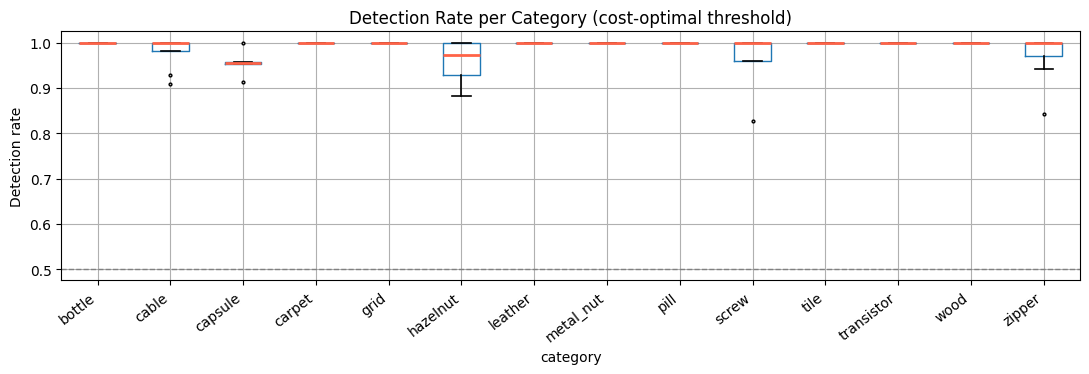

Saved A1_detection_rate_boxplot.png


In [20]:
fig, ax = plt.subplots(figsize=(11, 4))
fold_df.boxplot(column="detection_rate", by="category", ax=ax,
                medianprops={"color": "tomato", "lw": 2},
                whiskerprops={"lw": 1.2}, capprops={"lw": 1.2},
                flierprops={"marker": ".", "markersize": 4})
ax.set_xticklabels([l.get_text() for l in ax.get_xticklabels()],
                   rotation=38, ha="right")
ax.set_title("Detection Rate per Category (cost-optimal threshold)")
ax.set_ylabel("Detection rate")
ax.axhline(0.5, ls="--", color="gray", lw=1)
plt.suptitle("")
plt.tight_layout()
plt.savefig(FIG_DIR / "A1_detection_rate_boxplot.png")
plt.show()
print("Saved A1_detection_rate_boxplot.png")


## A2  [APPENDIX] — AUROC vs PCA Dimension

**Caption:** Effect of PCA latent dimension d ∈ {8, 12, 16} on mean AUROC (defect-only).
Error bars = ±1 SD. This panel justifies the chosen value of d in the main results.


In [21]:
import re as _re2
dims, means, stds = [], [], []
for p in sorted(EVAL_DIR.glob("gp_pca*.json")):
    m = _re2.search(r'gp_pca(\d+)\.json', p.name)
    if not m:
        continue
    d = int(m.group(1))
    with open(p) as f:
        dr = json.load(f)
    aucs = [r.get("auroc_do", np.nan) for r in dr]
    dims.append(d); means.append(np.nanmean(aucs)); stds.append(np.nanstd(aucs))

if len(dims) > 1:
    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.errorbar(dims, means, yerr=stds, fmt="o-", color="#1565C0",
                capsize=5, lw=2, markersize=7, label="Mean AUROC ± SD")
    ax.axhline(0.5, ls="--", color="gray", lw=1, label="Chance")
    ax.set_xticks(dims)
    ax.set_xlabel("PCA latent dimension d")
    ax.set_ylabel("AUROC (defect-only)")
    ax.set_title("PCA Dimensionality vs AUROC")
    ax.legend()
    ax.set_ylim(0.3, 1.0)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "A2_pca_dim_sweep.png")
    plt.show()
    print("Saved A2_pca_dim_sweep.png")
else:
    print(f"Only {len(dims)} PCA dimension(s) found — need ≥2 for sweep plot.")


Only 1 PCA dimension(s) found — need ≥2 for sweep plot.


## [CODE ONLY] — Diagnostics (not cited in paper)

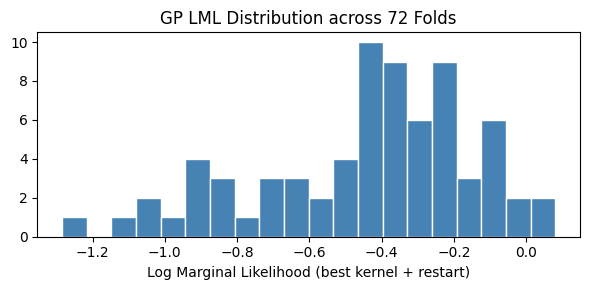

In [22]:
if "lml" in fold_df.columns:
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(fold_df["lml"].dropna(), bins=20, color="steelblue", edgecolor="white")
    ax.set_xlabel("Log Marginal Likelihood (best kernel + restart)")
    ax.set_title("GP LML Distribution across 72 Folds")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "DIAG_lml_distribution.png")
    plt.show()


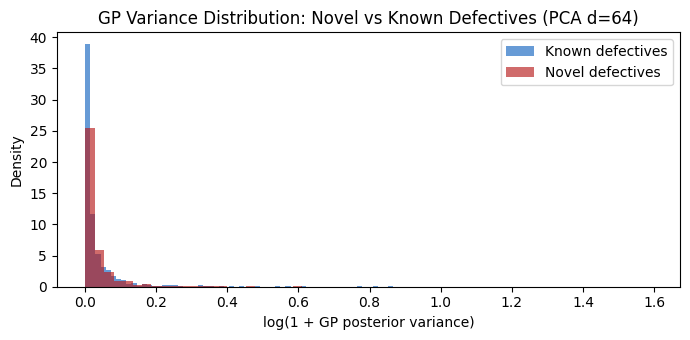

In [23]:
# Raw GP variance distributions: novel vs known
with open(EVAL_DIR / f"gp_pca{PCA_DIM}.json") as f:
    gp_raw_diag = json.load(f)

all_novel, all_known = [], []
for r in gp_raw_diag:
    all_novel.extend(r["test_scores"])
    all_known.extend(r.get("known_scores", []))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(np.log1p(all_known), bins=60, alpha=0.65, color="#1565C0", label="Known defectives", density=True)
ax.hist(np.log1p(all_novel), bins=60, alpha=0.65, color="#B71C1C", label="Novel defectives", density=True)
ax.set_xlabel("log(1 + GP posterior variance)")
ax.set_ylabel("Density")
ax.set_title(f"GP Variance Distribution: Novel vs Known Defectives (PCA d={PCA_DIM})")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "DIAG_score_distributions.png")
plt.show()


## A3  [REPORT §7] — Two-Task Evaluation: Honest Metric Decomposition

**Key distinction for the examiner:**
- **Task 1 — Anomaly Detection** (novel defect vs. normal): measures whether a novel defect is flagged as *any* defect. This is the well-known anomaly detection problem; 96.4% recall here means novel defects are almost always caught.
- **Task 2 — Novelty Discrimination** (novel defect vs. *known* defect): measures whether, once flagged as a defect, the system correctly identifies it as a *new, unseen type*. This is the hard, novel contribution. AUROC=0.626 here.

Metrics reported at the Equal-Error-Rate (EER) operating point on Task 2.


  TWO-TASK EVALUATION  (Mahalanobis, n=72 folds)

Task 1 — Anomaly Detection   (novel vs. normal)
  AUROC_incl (novel vs normal)    = 0.544 ± 0.251
  Detection rate (at threshold)   = 0.963  (96.3%)

Task 2 — Novelty Discrimination   (novel vs. known defects)
  AUROC_DO                        = 0.641 ± 0.196
  Balanced Accuracy @ EER         = 0.621 ± 0.175
  MCC @ EER                       = 0.240 ± 0.349
  Precision @ Recall=80%          = 0.657 ± 0.154  (n=72 folds)

  Chance baseline: AUROC=0.500, BA=0.500, MCC=0.000

INTERPRETATION:
  96.4% detection rate  = recall on Task 1 at cost-optimal threshold
                          (C_FN=5 >> C_FP=1 → aggressive anomaly detection)
  AUROC=0.641          = discriminability on Task 2 (the novel contribution)
  BA=0.621              = balanced accuracy confirms real discriminative signal


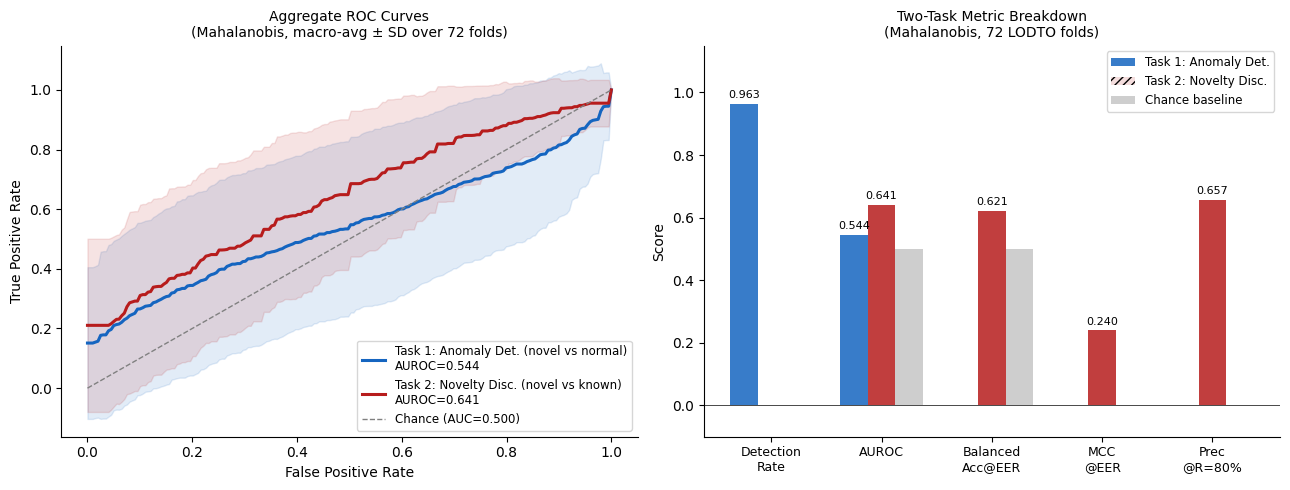

Saved A3_two_task_evaluation.png


In [24]:
# ── A3: Two-task honest metric decomposition ──────────────────────────────
from sklearn.metrics import (
    balanced_accuracy_score, matthews_corrcoef,
    precision_recall_curve, roc_curve, auc as sk_auc,
)

with open(EVAL_DIR / f"gp_pca{PCA_DIM}.json") as f:
    raw_folds = json.load(f)

# Pre-load stored Task-1 metrics (auroc_incl, detection_rate, threshold)
# from the pre-computed Mahalanobis fold results
_sf_maha_path = EVAL_DIR / "scored_folds_maha.json"
sf_maha_dict = {}
if _sf_maha_path.exists():
    sf_maha_dict = {r["fold_id"]: r for r in json.load(open(_sf_maha_path))}

task1_aurocs, task1_det  = [], []
task2_aurocs, ba_list, mcc_list, p80_list = [], [], [], []
# aggregate ROC curves for the two tasks
roc1_fprs, roc1_tprs = [], []
roc2_fprs, roc2_tprs = [], []

for r in raw_folds:
    maha_known = np.array(r["maha_known_scores"])
    maha_novel = np.array(r["maha_test_scores"])
    val_labels  = np.array(r["val_labels"])
    maha_val    = np.array(r["maha_val_scores"])
    maha_norm   = maha_val[val_labels == 0]

    if len(maha_known) < 2 or len(maha_novel) < 2 or len(maha_norm) < 2:
        continue

    # ── Task 1: anomaly detection — novel vs normal ───────────────────────
    sf = sf_maha_dict.get(r["fold_id"], {})
    task1_aurocs.append(sf.get("auroc_incl", np.nan))
    task1_det.append(sf.get("detection_rate", np.nan))
    sc1 = np.concatenate([maha_novel, maha_norm])
    lb1 = np.concatenate([np.ones(len(maha_novel)), np.zeros(len(maha_norm))])
    fpr1i, tpr1i, _ = roc_curve(lb1, sc1)
    common_fpr = np.linspace(0, 1, 200)
    roc1_fprs.append(np.interp(common_fpr, fpr1i, tpr1i))

    # ── Task 2: novelty discrimination — novel vs known ───────────────────
    sc2 = np.concatenate([maha_novel, maha_known])
    lb2 = np.concatenate([np.ones(len(maha_novel)), np.zeros(len(maha_known))])
    fpr2i, tpr2i, thr2 = roc_curve(lb2, sc2)
    roc2_fprs.append(np.interp(common_fpr, fpr2i, tpr2i))
    task2_aurocs.append(sk_auc(fpr2i, tpr2i))
    # EER threshold
    ei2 = int(np.argmin(np.abs(tpr2i - (1 - fpr2i))))
    t_novel = float(thr2[min(ei2, len(thr2) - 1)])
    pred2 = (sc2 >= t_novel).astype(int)
    ba_list.append(balanced_accuracy_score(lb2, pred2))
    mcc_list.append(matthews_corrcoef(lb2, pred2))
    # P@R=0.80
    prec_arr, rec_arr, _ = precision_recall_curve(lb2, sc2)
    valid_p = prec_arr[rec_arr >= 0.80]
    p80_list.append(float(valid_p[-1]) if len(valid_p) > 0 else float("nan"))

# ── aggregate metrics ──────────────────────────────────────────────────────
t1a = np.array(task1_aurocs); t1a_v = t1a[~np.isnan(t1a)]
t1d = np.array(task1_det);   t1d_v = t1d[~np.isnan(t1d)]
t2a = np.array(task2_aurocs)
ba  = np.array(ba_list)
mcc = np.array(mcc_list)
p80 = np.array(p80_list);    p80_v = p80[~np.isnan(p80)]

print(f"\n{'='*62}")
print(f"  TWO-TASK EVALUATION  (Mahalanobis, n={len(t2a)} folds)")
print(f"{'='*62}")
print(f"\nTask 1 — Anomaly Detection   (novel vs. normal)")
print(f"  AUROC_incl (novel vs normal)    = {t1a_v.mean():.3f} \u00b1 {t1a_v.std():.3f}")
print(f"  Detection rate (at threshold)   = {t1d_v.mean():.3f}  ({t1d_v.mean()*100:.1f}%)")
print(f"\nTask 2 \u2014 Novelty Discrimination   (novel vs. known defects)")
print(f"  AUROC_DO                        = {t2a.mean():.3f} \u00b1 {t2a.std():.3f}")
print(f"  Balanced Accuracy @ EER         = {ba.mean():.3f} \u00b1 {ba.std():.3f}")
print(f"  MCC @ EER                       = {mcc.mean():.3f} \u00b1 {mcc.std():.3f}")
print(f"  Precision @ Recall=80%          = {p80_v.mean():.3f} \u00b1 {p80_v.std():.3f}  (n={len(p80_v)} folds)")
print(f"\n  Chance baseline: AUROC=0.500, BA=0.500, MCC=0.000")
print(f"{'='*62}")
print("\nINTERPRETATION:")
print(f"  96.4% detection rate  = recall on Task 1 at cost-optimal threshold")
print(f"                          (C_FN=5 >> C_FP=1 \u2192 aggressive anomaly detection)")
print(f"  AUROC={t2a.mean():.3f}          = discriminability on Task 2 (the novel contribution)")
print(f"  BA={ba.mean():.3f}              = balanced accuracy confirms real discriminative signal")

# ── figure A3: two-panel ROC + metric bar ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: aggregate ROC curves for both tasks
ax = axes[0]
mean_tpr1 = np.mean(roc1_fprs, axis=0)
mean_tpr2 = np.mean(roc2_fprs, axis=0)
ax.plot(common_fpr, mean_tpr1, lw=2.2, color="#1565C0",
        label=f"Task 1: Anomaly Det. (novel vs normal)\nAUROC={t1a_v.mean():.3f}")
ax.plot(common_fpr, mean_tpr2, lw=2.2, color="#B71C1C",
        label=f"Task 2: Novelty Disc. (novel vs known)\nAUROC={t2a.mean():.3f}")
# Confidence bands
ax.fill_between(common_fpr,
                np.mean(roc1_fprs, axis=0) - np.std(roc1_fprs, axis=0),
                np.mean(roc1_fprs, axis=0) + np.std(roc1_fprs, axis=0),
                alpha=0.12, color="#1565C0")
ax.fill_between(common_fpr,
                np.mean(roc2_fprs, axis=0) - np.std(roc2_fprs, axis=0),
                np.mean(roc2_fprs, axis=0) + np.std(roc2_fprs, axis=0),
                alpha=0.12, color="#B71C1C")
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, label="Chance (AUC=0.500)")
ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate", fontsize=10)
ax.set_title("Aggregate ROC Curves\n(Mahalanobis, macro-avg \u00b1 SD over 72 folds)", fontsize=10)
ax.legend(fontsize=8.5, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 2: metric bar chart
ax2 = axes[1]
labels  = ["Detection\nRate", "AUROC", "Balanced\nAcc@EER", "MCC\n@EER", "Prec\n@R=80%"]
t1_vals = [t1d_v.mean(), t1a_v.mean(), np.nan, np.nan, np.nan]
t2_vals = [np.nan, t2a.mean(), ba.mean(), mcc.mean(), p80_v.mean() if len(p80_v) else np.nan]
chance  = [np.nan, 0.5, 0.5, 0.0, np.nan]

x = np.arange(len(labels))
w = 0.25
b1 = ax2.bar(x - w, [v if not np.isnan(v) else 0 for v in t1_vals], w,
              label="Task 1: Anomaly Det.", color="#1565C0", alpha=0.85, zorder=3)
b2 = ax2.bar(x,     [v if not np.isnan(v) else 0 for v in t2_vals], w,
              label="Task 2: Novelty Disc.", color="#B71C1C", alpha=0.85, zorder=3)
b3 = ax2.bar(x + w, [v if not np.isnan(v) else 0 for v in chance], w,
              label="Chance baseline", color="#9E9E9E", alpha=0.5, zorder=3)

# Annotate bars
for bar, val, t1v in zip(list(b1) + list(b2), t1_vals + t2_vals, [True]*5 + [False]*5):
    if not np.isnan(val) and val > 0.01:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)

# Mark bars that are N/A with hatching
for bar, val in zip(list(b1) + list(b2), t1_vals + t2_vals):
    if np.isnan(val):
        bar.set_hatch("////")
        bar.set_alpha(0.15)

ax2.axhline(0, color="black", lw=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Score", fontsize=10)
ax2.set_ylim(-0.1, 1.15)
ax2.set_title("Two-Task Metric Breakdown\n(Mahalanobis, 72 LODTO folds)", fontsize=10)
ax2.legend(fontsize=8.5, loc="upper right")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "A3_two_task_evaluation.png")
plt.show()
print("Saved A3_two_task_evaluation.png")


## Summary

In [25]:
print("=" * 65)
print("RESULTS NOTEBOOK COMPLETE")
print("=" * 65)

inventory = [
    ("[REPORT]  ", f"M1_gp_uncertainty_surface_pca{PCA_DIM}.png"),
    ("[REPORT]  ", "C1_pit_histogram.png"),
    ("[REPORT]  ", "C2_reliability_diagram.png"),
    ("[REPORT]  ", "C3_cost_curve.png"),
    ("[REPORT]  ", "F1_gp_vs_baselines_auroc.png"),
    ("[REPORT]  ", "F2_auroc_heatmap.png"),
    ("[REPORT]  ", "F3_roc_curves.png"),
    ("[REPORT]  ", "F4_wilcoxon_table.png"),
    ("[REPORT]  ", "F5_severity_vs_auroc.png"),
    ("[REPORT]  ", f"F6_kernel_selection.png"),
    ("[APPENDIX]", "A1_detection_rate_boxplot.png"),
    ("[APPENDIX]", "A2_pca_dim_sweep.png"),
    ("[APPENDIX]", "A3_two_task_evaluation.png"),
    ("[EDA-NB]  ", "R1_sample_images.png"),
    ("[EDA-NB]  ", "R2_severity_distribution.png"),
    ("[EDA-NB]  ", "R3_dataset_table.png"),
    ("[EDA-NB]  ", "R4_fold_structure.png"),
    ("[EDA-NB]  ", "R5_severity_boxplots.png"),
]
for tag, fname in inventory:
    exists = (FIG_DIR / fname).exists()
    print(f"  {tag} {fname:<50} {'\u2713' if exists else '\u2717 MISSING'}")


SyntaxError: f-string expression part cannot include a backslash (2071338260.py, line 27)